**TASK** : CIFAR - 10 Colour ٰImage Classification
This notebook implements a deep Convolutional Neural Network (CNN) to classify real world colour images, representing a significant increase in complexity over the previous tasks.

**GOAL** : Building a high-performing classifier capable of distinguishing between 10 distinct object classes.

**DATA** : CIFAR - 10 dataset, consisting of 60,000 32 x 32 pixel colour (RGB) images, separated into 10 categories.

**METHOD** : We employ a multi-block, deep CNN architecture utilizing Conv2D layers, Batch Normalization (BN) for training stability, and Dropout for regularization to handle the high-dimensional, complex features of real-world colour imagery.

In [34]:
# importing necessary libraries
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


In [7]:
# define class names (cifar-10 has 10 specific categories)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog','frog', 'horse','ship','truck']


In [8]:
# loading dataset
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = cifar10.load_data()

In [11]:
# preprocessing
img_rows, img_cols = 32, 32
num_classes = 10
input_shape = (img_rows, img_cols, 3)

In [12]:
# normalization: [0: 255] -> [0.0, 1.0]
X_train = X_train_raw.astype('float32') / 255.0
X_test = X_test_raw.astype('float32') / 255.0

# one-hot Encoded Labels
y_train = to_categorical(y_train_raw, num_classes)
y_test = to_categorical(y_test_raw, num_classes)

print(f"X_train_shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train_shape: (50000, 32, 32, 3)
y_train shape: (50000, 10)



Plotting Sample color images to confirm data integrity


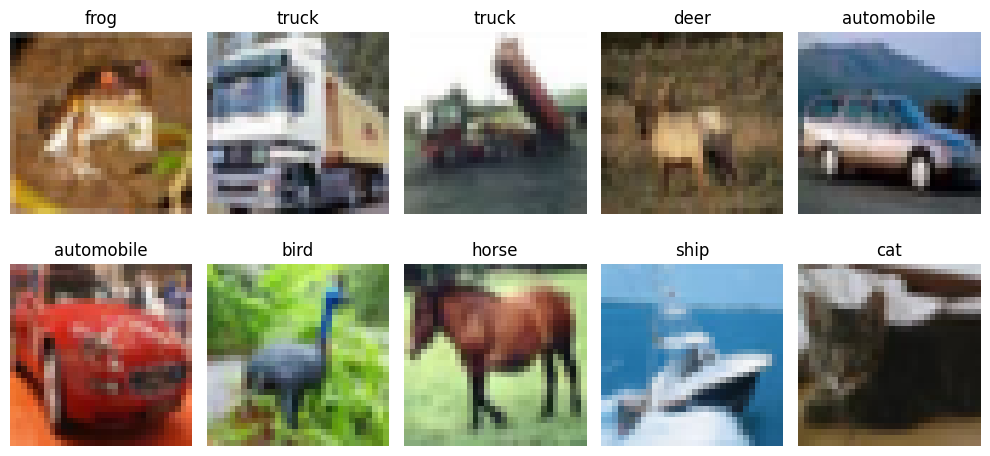

In [13]:
# Data Sanity check and Class visualisation
print("\nPlotting Sample color images to confirm data integrity")

plt.figure(figsize = (10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    # we plot X_train directly since it is already (32, 32, 3)
    plt.imshow(X_train_raw[i])
    plt.title(f"{class_names[y_train_raw[i][0]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [17]:
# CNN model architecture (Deeper for complexity)
# create sequential model container
model = Sequential()
input_shape = (img_rows, img_cols, 3)

# BLOCK - 1
model.add(Conv2D(32, (3,3), padding = 'same', activation = 'relu', input_shape=input_shape))
model.add(BatchNormalization())
model.add(Conv2D(32, (3, 3), activation = 'relu')) # notice we did not add padding here, means padding = 'valid', the outputs will be slightly smaller than inputs
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Dropout(0.2)) # it will drop 20% of the features from the previous layer to prevent overfitting

# BLOCK - 2
model.add(Conv2D(64, (3,3), padding='same', activation = 'relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Dropout(0.3))

# BLOCK - 3
model.add(Conv2D(128, (3, 3), padding = 'same', activation = 'relu', ))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Dropout(0.4))

# DENSE (Fully connected) HEAD
model.add(Flatten())
model.add(Dense(512, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation = 'softmax'))

model.summary

<bound method Model.summary of <Sequential name=sequential_2, built=True>>

In [18]:
# compile the model
model.compile(
    loss = 'categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [19]:
# train the model
batch_size = 64 # reduced batch_size slightly for better generalization
epochs = 20 # increased epochs are generally needed for CIFAR-10 dataset

print(f"\nStarting model training, be patient...")


Starting model training, be patient...


In [20]:
# dedicated test set for validation during test
history = model.fit(
    X_train, y_train,
    batch_size = batch_size,
    epochs = epochs,
    verbose = 1,
    validation_data = (X_test, y_test)
)
print("\nTraining complete!")

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 140s 174ms/step - accuracy: 0.3264 - loss: 1.9140 - val_accuracy: 0.2496 - val_loss: 2.6929
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 135s 172ms/step - accuracy: 0.5554 - loss: 1.2515 - val_accuracy: 0.6241 - val_loss: 1.0668
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 172ms/step - accuracy: 0.6256 - loss: 1.0628 - val_accuracy: 0.6218 - val_loss: 1.0633
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 134s 172ms/step - accuracy: 0.6730 - loss: 0.9400 - val_accuracy: 0.7052 - val_loss: 0.8268
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 135s 172ms/step - accuracy: 0.7034 - loss: 0.8597 - val_accuracy: 0.7352 - val_loss: 0.7718
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 143s 173ms/step - accuracy: 0.7282 - loss: 0.7954 - val_accuracy: 0.7369 - val_loss: 0.7456
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 134s 172ms/step - accuracy: 0.7408 - loss: 0.7488 - val_accuracy: 0.7483 - val_loss: 0.7405
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 136s 174ms/step - accuracy: 0.7631 -

In [24]:
# evaluating the model
score = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal test loss: {score[0]:.4f}")
print(f"\nFinal test accuracy: {score[1] * 100:.2f}%")


Final test loss: 0.5701

Final test accuracy: 81.72%


In [22]:
# preparing labels for reporting
y_pred_probs = model.predict(X_test)
y_true_labels = y_test_raw.flatten() # Flattern (N, 1) array back to (N,)
y_pred_labels = np.argmax(y_pred_probs, axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


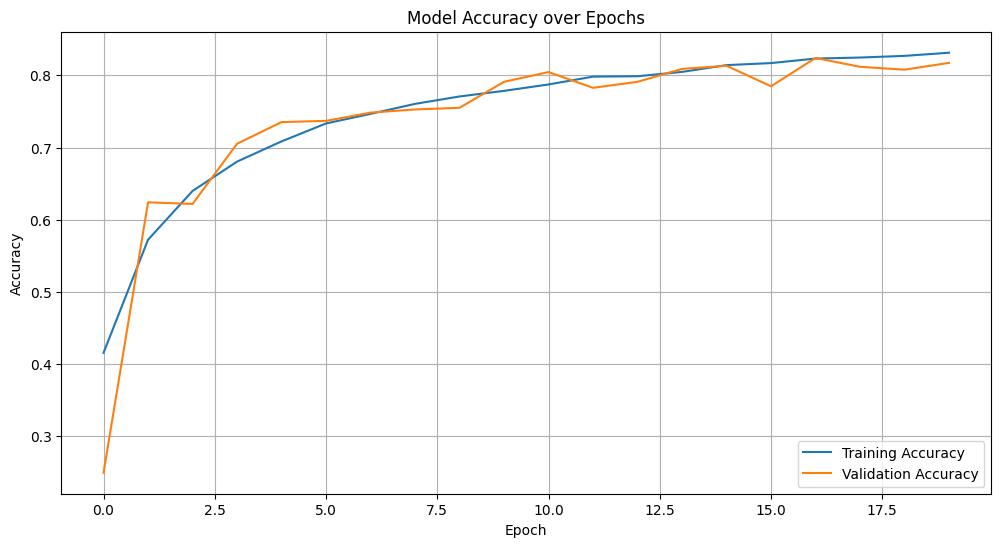

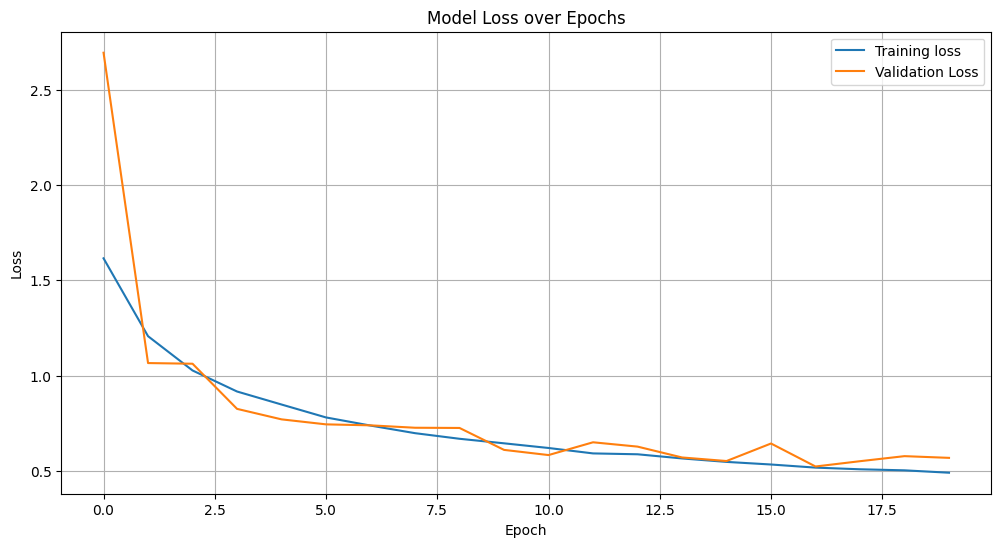

In [31]:
# PLOT 1: Accuracy History
plt.figure(figsize = (12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label= 'Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc= 'lower right')
plt.grid(True)
plt.show()

# PLOT 2: Loss History
plt.figure(figsize = (12, 6))
plt.plot(history.history['loss'], label = 'Training loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.title('Model Loss over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc= 'upper right')
plt.grid(True)
plt.show()

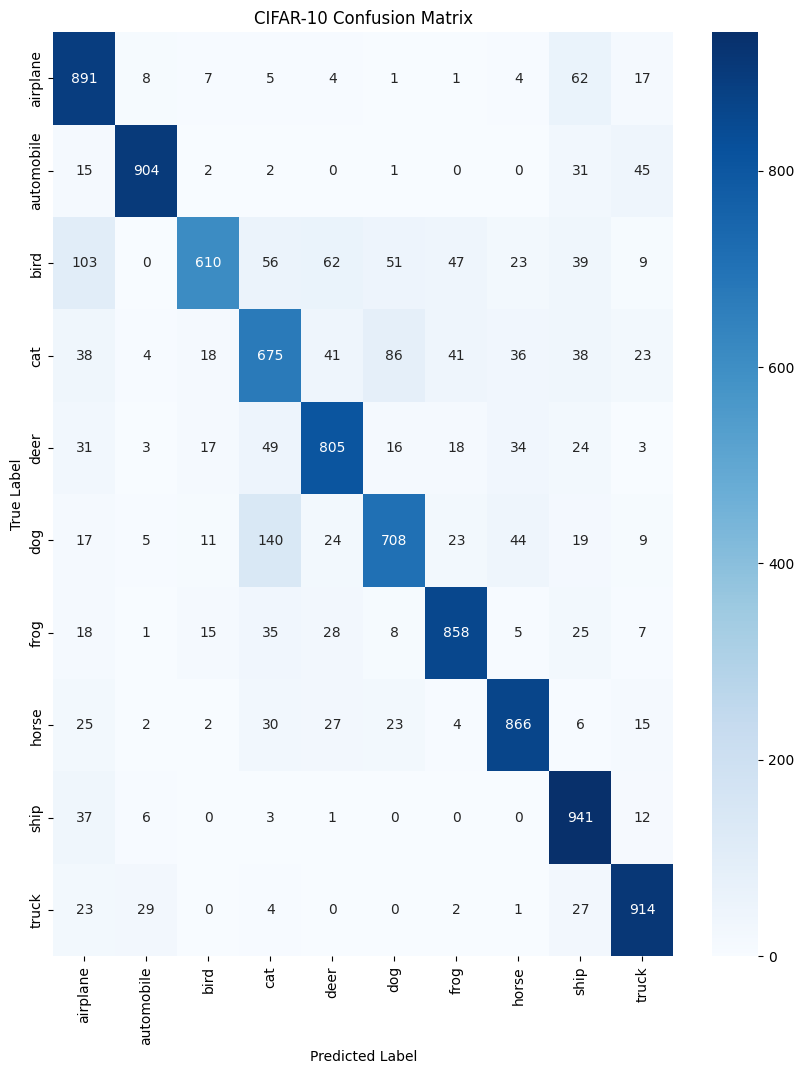


Detailed Classification Report (Per Item Type)

              precision    recall  f1-score   support

    airplane       0.74      0.89      0.81      1000
  automobile       0.94      0.90      0.92      1000
        bird       0.89      0.61      0.73      1000
         cat       0.68      0.68      0.68      1000
        deer       0.81      0.81      0.81      1000
         dog       0.79      0.71      0.75      1000
        frog       0.86      0.86      0.86      1000
       horse       0.85      0.87      0.86      1000
        ship       0.78      0.94      0.85      1000
       truck       0.87      0.91      0.89      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



In [35]:
conf_mat = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize = (10, 12))
sns.heatmap(
    conf_mat,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    xticklabels = class_names,
    yticklabels = class_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CIFAR-10 Confusion Matrix')
plt.show()

# Classification report summary
print("\nDetailed Classification Report (Per Item Type)\n")
print(classification_report(y_true_labels, y_pred_labels, target_names = class_names))
